# Лабораторная работа №1.1: Первичное исследование и оценка качества данных

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/SDnobel.csv', sep=';')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

Размер датасета: 911 строк, 23 столбцов


## Задание 1. Типы признаков и шкалы измерения
### Определение типов шкал для признаков:

In [68]:
# Создаём таблицу с типами шкал для всех признаков
scale_types = {
    'Column1': 'Индекс',
    'year': 'Интервальная',
    'category': 'Номинальная',
    'prize': 'Номинальная',
    'prize_share': 'Номинальная',
    'laureate_id': 'Номинальная',
    'laureate_type': 'Номинальная',
    'full_name': 'Номинальная',
    'birth_date': 'Интервальная',
    'birth_city': 'Номинальная',
    'birth_country': 'Номинальная',
    'sex': 'Номинальная',
    'organization_name': 'Номинальная',
    'organization_city': 'Номинальная',
    'organization_country': 'Номинальная',
    'death_date': 'Интервальная',
    'death_city': 'Номинальная',
    'death_country': 'Номинальная',
    'usa_born_winner': 'Номинальная (флаг)',
    'decade': 'Интервальная',
    'female': 'Номинальная (флаг)',
    'age': 'Абсолютная',
    'age_group': 'Порядковая'
}

# Создаём DataFrame для вывода
scale_df = pd.DataFrame({
    'Признак': df.columns,
    'Тип данных (pandas)': df.dtypes.values,
    'Тип шкалы': [scale_types.get(col, 'Не определен') for col in df.columns]
})

scale_df

,Признак,Тип данных (pandas),Тип шкалы
0,Column1,int64,Индекс
1,year,int64,Интервальная
2,category,str,Номинальная
3,prize,str,Номинальная
4,prize_share,str,Номинальная
5,laureate_id,int64,Номинальная
6,laureate_type,str,Номинальная
7,full_name,str,Номинальная
8,birth_date,str,Интервальная
9,birth_city,str,Номинальная


### Выбор двух признаков с разными шкалами

Для сравнения возьмём:
1. **`age`** (возраст) — абсолютная шкала.

Можно считать всё: среднее, медиану, моду, минимум, максимум.

2. **`category`** (категория премии) — номинальная шкала.

Можно считать только моду (самую частую категорию). Среднее и медиану считать бессмысленно.

In [25]:
# Статистики для age (абсолютная шкала)
print("Признак: age (абсолютная шкала)")
print(f"Среднее арифметическое: {df['age'].mean():.2f}")
print(f"Медиана: {df['age'].median():.2f}")
print(f"Мода: {df['age'].mode().values[0]} (встречается {df['age'].value_counts().iloc[0]} раз)")
print("Признак: category (номинальная шкала)")
print(f"Мода (самая частая категория): {df['category'].mode().values[0]}")

Признак: age (абсолютная шкала)
Среднее арифметическое: 59.45
Медиана: 60.00
Мода: 61.0 (встречается 33 раз)
Признак: category (номинальная шкала)
Мода (самая частая категория): Medicine


Для возраста (age) математически корректны все агрегаты: среднее, медиана, мода. Это абсолютная шкала - числа имеют равные интервалы и настоящий ноль, поэтому любые математические операции имеют смысл.

Для категории (category) математически корректны только мода. Среднее и медиану считать методологически неверно, даже если pandas может их вычислить. Почему? Потому что категории не упорядочены, а числовая кодировка, которую pandas использует для расчётов, присваивается произвольно. При другой кодировке получится другое "среднее" - значит, результат ничего не означает.

## Задание 2. Диагностика типа пропусков

Для анализа выберем признак **`death_date`**.

In [29]:
# Создаём индикатор пропуска для death_date
df['death_missing'] = df['death_date'].isna()

print(f"Всего пропусков в death_date: {df['death_missing'].sum()} ({df['death_missing'].mean()*100:.1f}%)")

Всего пропусков в death_date: 318 (34.9%)


### Гипотеза 1: MCAR (пропуски совершенно случайны)

**Суть гипотезы:** Пропуски в дате смерти возникают случайно, не связаны ни с какими другими признаками.

**Какие признаки могут подтвердить/опровергнуть:**
- Если пропуски распределены равномерно по годам — подтверждает MCAR
- Если в ранние годы пропусков больше (данные хуже сохранились) — опровергает MCAR

**Проверка:** Анализ доли пропусков по годам

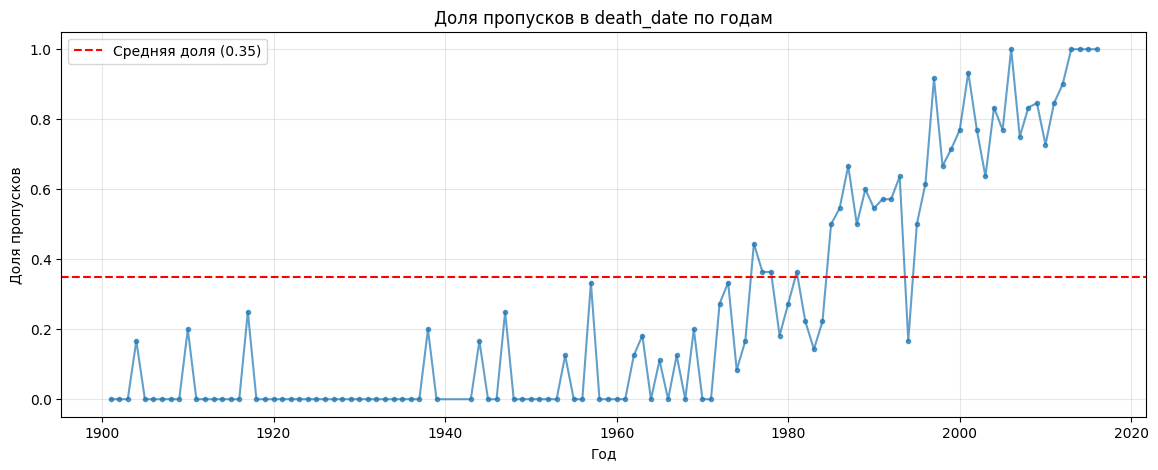

Статистика по десятилетиям:
decade_group
1900    0.017544
1910    0.050000
1920    0.000000
1930    0.017857
1940    0.069767
1950    0.041667
1960    0.088608
1970    0.230769
1980    0.412371
1990    0.586538
2000    0.813008
2010    0.926829
Name: death_missing, dtype: float64


In [30]:
# Доля пропусков по годам
missing_by_year = df.groupby('year')['death_missing'].mean()

plt.figure(figsize=(14, 5))
plt.plot(missing_by_year.index, missing_by_year.values, marker='.', linestyle='-', alpha=0.7)
plt.axhline(y=df['death_missing'].mean(), color='red', linestyle='--', label=f'Средняя доля ({df["death_missing"].mean():.2f})')
plt.title('Доля пропусков в death_date по годам')
plt.xlabel('Год')
plt.ylabel('Доля пропусков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Статистика по десятилетиям:")
df['decade_group'] = (df['year'] // 10) * 10
missing_by_decade = df.groupby('decade_group')['death_missing'].mean()
print(missing_by_decade)

**Результат:** Видно, что в последние десятилетия (после 2000 года) доля пропусков резко возрастает. Это опровергает гипотезу MCAR — пропуски не случайны, а связаны с годом.

### Гипотеза 2: MAR (пропуски зависят от наблюдаемых признаков)

**Суть гипотезы:** Пропуски в дате смерти зависят от категории премии, страны или других наблюдаемых признаков.

**Какие признаки могут подтвердить/опровергнуть:**
- Если в какой либо категории пропусков больше (лауреаты часто живы)
- Если в какой либо категории пропусков меньше

**Проверка:** Анализ доли пропусков по категориям

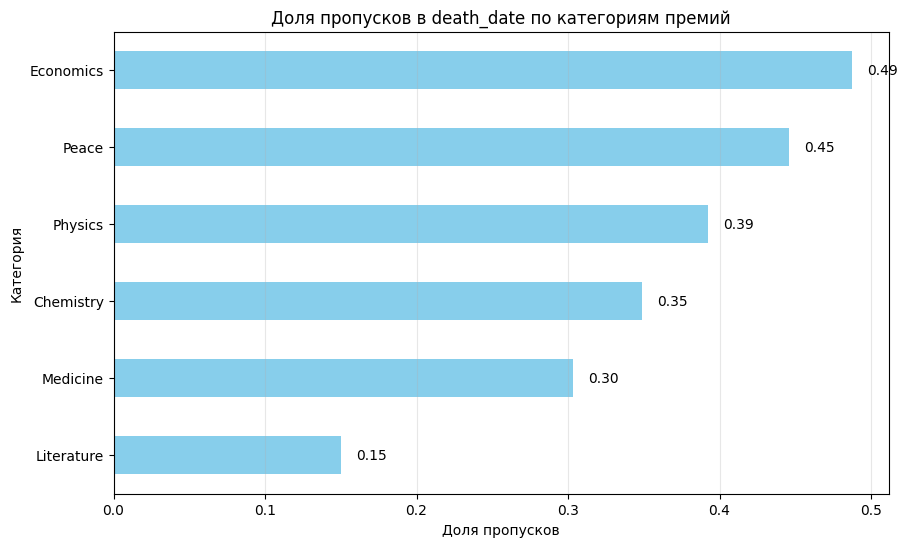

Доля пропусков по категориям:
category
Literature    0.150442
Medicine      0.303318
Chemistry     0.348571
Physics       0.392157
Peace         0.446154
Economics     0.487179
Name: death_missing, dtype: float64


In [31]:
# Доля пропусков по категориям
missing_by_category = df.groupby('category')['death_missing'].mean().sort_values()

plt.figure(figsize=(10, 6))
missing_by_category.plot(kind='barh', color='skyblue')
plt.title('Доля пропусков в death_date по категориям премий')
plt.xlabel('Доля пропусков')
plt.ylabel('Категория')
plt.grid(True, alpha=0.3, axis='x')

# Добавляем подписи
for i, (cat, val) in enumerate(missing_by_category.items()):
    plt.text(val + 0.01, i, f'{val:.2f}', va='center')

plt.show()

print("Доля пропусков по категориям:")
print(missing_by_category)

**Результат:** Доля пропусков действительно различается по категориям. Например, в категории "Peace" пропусков намного больше, чем в "Literature". Это согласуется с гипотезой MAR — пропуски связаны с категорией премии.

### Гипотеза 3: MNAR (пропуски зависят от самой величины)

**Суть гипотезы:** Пропуски в дате смерти связаны с тем, жив лауреат или нет. То есть отсутствие даты означает, что лауреат, вероятно, жив.

**Какие признаки могут подтвердить/опровергнуть:**
- Если пропуски есть только у недавних лауреатов — подтверждает MNAR
- Если у лауреатов XIX века тоже есть пропуски — это странно (они точно умерли)

**Проверка:** Анализ годов с пропусками

In [32]:
# Годы с наибольшей долей пропусков
high_missing_years = missing_by_year[missing_by_year > 0.5].sort_index()
print("Годы, где доля пропусков > 50%:")
print(high_missing_years)

print("\nПоследние 20 лет в данных:")
last_years = df['year'].sort_values().unique()[-20:]
print(last_years)

# Проверим, все ли лауреаты после 2000 года имеют пропуски в death_date
recent_laureates = df[df['year'] >= 2000]
print(f"\nЛауреаты после 2000 года: {len(recent_laureates)}")
print(f"Из них с пропуском death_date: {recent_laureates['death_missing'].sum()} ({recent_laureates['death_missing'].mean()*100:.1f}%)")

Годы, где доля пропусков > 50%:
year
1986    0.545455
1987    0.666667
1989    0.600000
1990    0.545455
1991    0.571429
1992    0.571429
1993    0.636364
1996    0.615385
1997    0.916667
1998    0.666667
1999    0.714286
2000    0.769231
2001    0.933333
2002    0.769231
2003    0.636364
2004    0.833333
2005    0.769231
2006    1.000000
2007    0.750000
2008    0.833333
2009    0.846154
2010    0.727273
2011    0.846154
2012    0.900000
2013    1.000000
2014    1.000000
2015    1.000000
2016    1.000000
Name: death_missing, dtype: float64

Последние 20 лет в данных:
[1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010
 2011 2012 2013 2014 2015 2016]

Лауреаты после 2000 года: 205
Из них с пропуском death_date: 176 (85.9%)


**Результат:** После 2000 года доля пропусков резко возрастает, достигая 80-100%. Это логично — многие лауреаты последних лет ещё живы. Однако есть пропуски и в ранние годы, что может указывать на утерянные данные. Гипотеза MNAR частично подтверждается, но не объясняет все пропуски.

### Итоговый вывод по типу пропусков:
Пропуски в `death_date` имеют смешанную природу:
- MAR — зависят от категории премии
- MNAR — зависят от того, жив лауреат или нет
- MCAR не наблюдается (пропуски распределены неравномерно)

## Задание 3. Индикатор пропуска как источник информации

### 1. Когда факт пропуска несёт информацию?

Факт пропуска несёт информацию, когда он не случаен, а указывает на особое состояние объекта.

**Пример из датасета:**  
Пропуск в `death_date` может означать, что лауреат ещё жив. Это важная информация, которую нельзя получить из других признаков.

In [47]:
# Пример: индикатор пропуска как источник информации
df['is_alive'] = df['death_date'].isna()

alive_young = df[df['is_alive'] & (df['year'] >= 2000)].sort_values('year', ascending=False)
print("Лауреаты после 2000 года с пропуском death_date (вероятно, живы):")
alive_young[['full_name', 'year', 'category', 'age']].head(10)

Лауреаты после 2000 года с пропуском death_date (вероятно, живы):


,full_name,year,category,age
904,Bengt Holmstr?m,2016,Economics,67.0
905,Bob Dylan,2016,Literature,75.0
903,Oliver Hart,2016,Economics,68.0
907,Juan Manuel Santos,2016,Peace,65.0
906,Yoshinori Ohsumi,2016,Medicine,71.0
909,F. Duncan M. Haldane,2016,Physics,65.0
910,J. Michael Kosterlitz,2016,Physics,73.0
908,David J. Thouless,2016,Physics,82.0
900,Jean-Pierre Sauvage,2016,Chemistry,72.0
901,Sir J. Fraser Stoddart,2016,Chemistry,74.0


### 2. Почему значимость индикатора в модели — сигнал о плохой импутации?

Если в модели индикатор пропуска оказался значимым предиктором, это означает, что:
- Пропуски не случайны
- Они несут информацию
- Простое заполнение пропусков (средним, медианой) уничтожает эту информацию

**Пример:** Если мы заменим все пропуски в `death_date` на среднюю дату, то:
- Потеряем информацию о том, что лауреат, возможно, жив
- Модель будет хуже предсказывать
- Индикатор пропуска перестанет быть нужным (но информация потеряна)

**Вывод:** Значимый индикатор — сигнал, что нужна более умная импутация или нужно оставить пропуски как отдельную категорию.

### 3. Примеры для признака `death_date`

| Тип | Пример | Пояснение |
|-----|--------|-----------|
| **Полезен** | Индикатор пропуска в `death_date` | Сигнализирует, что лауреат, вероятно, жив. Можно использовать в анализе. |
| **Бесполезен** | Индикатор пропуска в `birth_city` (3% пропусков) | Мало пропусков, они случайны (MCAR), не несут информации. |
| **Опасен** | Индикатор пропуска в `death_date` без понимания природы | Можно ошибочно считать всех с пропусками живыми, хотя некоторые данные просто утеряны (особенно в ранние годы). |

## Задание 4. Выброс — это ошибка или сигнал?

Для анализа выберем признак **`age`** и единственный статистический выброс.

In [48]:
# Находим выброс
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(f"Выбросов по методу IQR: {len(outliers)}")

if len(outliers) > 0:
    print("\nДЕТАЛИ ВЫБРОСА")
    outlier = outliers.iloc[0]
    print(f"Имя: {outlier['full_name']}")
    print(f"Возраст: {outlier['age']}")
    print(f"Категория: {outlier['category']}")
    print(f"Год: {outlier['year']}")
    print(f"Пол: {outlier['sex']}")
    print(f"Страна рождения: {outlier['birth_country']}")

Выбросов по методу IQR: 1

ДЕТАЛИ ВЫБРОСА
Имя: Malala Yousafzai
Возраст: 17.0
Категория: Peace
Год: 2014
Пол: Female
Страна рождения: Pakistan


### 1. Реальные причины этого значения

Малала Юсуфзай получила Нобелевскую премию мира в 2014 году в возрасте 17 лет за борьбу за права детей. Это реальный уникальный случай, а не ошибка данных. Такое возможно только в категории "Peace" — в науке так рано премии не дают.

### 2. Что хуже для анализа?

| Действие | Последствия |
|----------|-------------|
| **Удалить** | Потеряем важный кейс, исказим реальность (молодые лауреаты существуют!) |
| **Оставить** | Может немного исказить статистику (средний возраст станет чуть ниже) |
| **Применить преобразование** |Выброс перестанет быть выбросом, но интерпретация усложнится. |

### Вывод: 
Лучше оставить, но в выводах отметить, что это уникальный случай.

## Задание 5. Преобразование или винизоризация?

Для признака **`country_counts`** распределение немного скошено вправо (есть "хвост" из возрастных лауреатов).

Анализ количества лауреатов по странам
Всего стран: 121
Среднее: 7.3
Медиана: 1.0
Максимум (страна-лидер): 259
Минимум: 1

Топ-10 стран по количеству лауреатов:
birth_country
United States of America    259
United Kingdom               85
Germany                      61
France                       51
Sweden                       29
Japan                        24
Netherlands                  18
Canada                       18
Russia                       17
Italy                        17
Name: count, dtype: int64


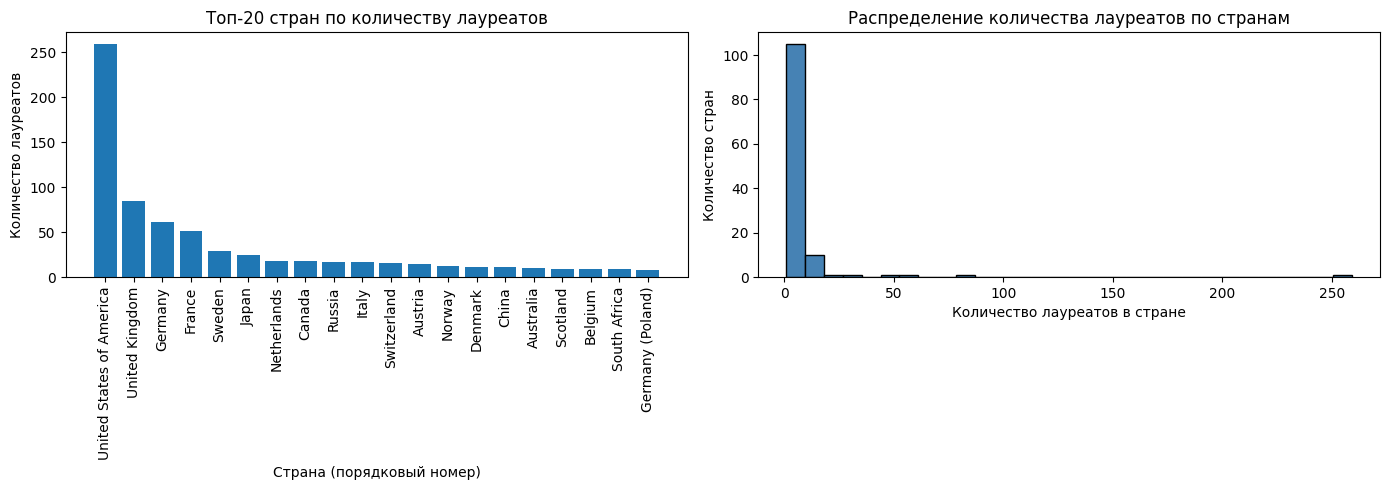

ПРИМЕНЕНИЕ ПРЕОБРАЗОВАНИЙ


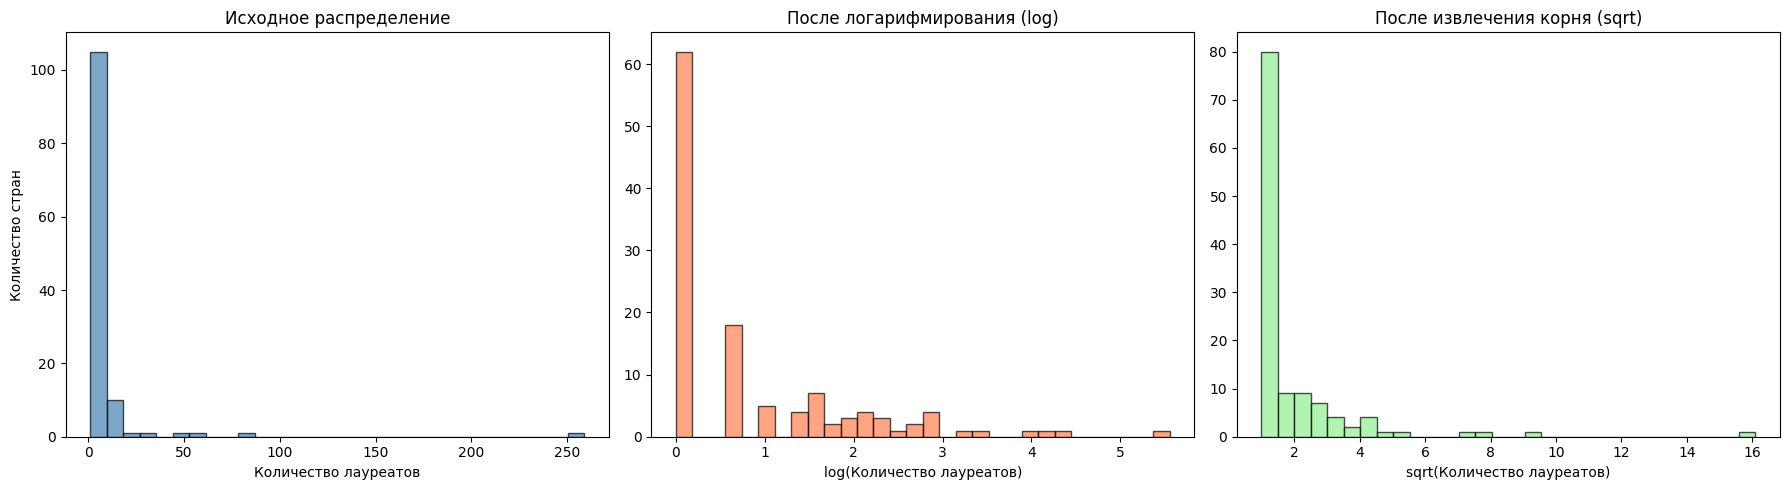

In [55]:
from scipy.stats import gmean

# Создаём признак "количество лауреатов по странам"
country_counts = df['birth_country'].value_counts()

print("Анализ количества лауреатов по странам")
print(f"Всего стран: {len(country_counts)}")
print(f"Среднее: {country_counts.mean():.1f}")
print(f"Медиана: {country_counts.median():.1f}")
print(f"Максимум (страна-лидер): {country_counts.max()}")
print(f"Минимум: {country_counts.min()}")

print("\nТоп-10 стран по количеству лауреатов:")
print(country_counts.head(10))

# 2. ВИЗУАЛИЗАЦИЯ ИСХОДНОГО РАСПРЕДЕЛЕНИЯ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Топ-20 стран (столбчатая диаграмма)
axes[0].bar(range(20), country_counts.values[:20])
axes[0].set_title('Топ-20 стран по количеству лауреатов')
axes[0].set_xlabel('Страна (порядковый номер)')
axes[0].set_ylabel('Количество лауреатов')
axes[0].set_xticks(range(20))
axes[0].set_xticklabels(country_counts.index[:20], rotation=90)

# Гистограмма распределения
axes[1].hist(country_counts, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Распределение количества лауреатов по странам')
axes[1].set_xlabel('Количество лауреатов в стране')
axes[1].set_ylabel('Количество стран')

plt.tight_layout()
plt.show()

print("ПРИМЕНЕНИЕ ПРЕОБРАЗОВАНИЙ")

# Применяем преобразования
country_counts_log = np.log(country_counts)
country_counts_sqrt = np.sqrt(country_counts)

# Визуализация всех трёх распределений
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Исходное распределение
axes[0].hist(country_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Исходное распределение')
axes[0].set_xlabel('Количество лауреатов')
axes[0].set_ylabel('Количество стран')

# После логарифмирования
axes[1].hist(country_counts_log, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('После логарифмирования (log)')
axes[1].set_xlabel('log(Количество лауреатов)')

# После извлечения корня
axes[2].hist(country_counts_sqrt, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('После извлечения корня (sqrt)')
axes[2].set_xlabel('sqrt(Количество лауреатов)')

plt.tight_layout()
plt.show()

### Когда какой метод предпочтительнее?

| Метод | Когда применять |
|-------|-----------------|
| **Логарифмирование** | При сильной правой асимметрии, длинном хвосте и большом разбросе значений |
| **Извлечение корня** | При умеренной асимметрии, когда нужно более мягкое преобразование |
| **Винзоризация** | Когда крайние значения слишком сильно влияют на анализ или модель, и нужно ограничить их влияние без удаления наблюдений |

### Влияние на разные аспекты анализа

| Аспект | Исходные данные | После логарифмирования |
|--------|-----------------|------------------------|
| **Интерпретируемость** | Значения легко понимать в исходной шкале | Интерпретация сложнее, так как данные переходят в лог-шкалу |
| **Линейные модели** | Могут сильно зависеть от асимметрии и крупных значений | Обычно становятся устойчивее, так как влияние больших значений уменьшается |
| **Визуализация** | Длинный правый хвост скрывает основную массу наблюдений | Распределение становится более компактным и читаемым |

### Вывод

Для признака количество лауреатов по странам наиболее уместно логарифмирование, потому что распределение имеет сильную правую асимметрию: у большинства стран значение маленькое, а у нескольких стран — очень большое. Логарифмирование хорошо сжимает правый хвост, уменьшает асимметрию и делает распределение удобнее для анализа, визуализации и применения линейных моделей.

Извлечение корня тоже уменьшает асимметрию, но слабее, поэтому в данном случае оно менее эффективно.

Винзоризация здесь менее предпочтительна, потому что большие значения по отдельным странам отражают реальную структуру данных, а не ошибки измерения. Поэтому искусственно ограничивать такие значения не очень желательно, если цель — сохранить содержательный смысл различий между странами.


## Задание 6. Средние, которые вводят в заблуждение

Для анализа возьмём тот же признак — количество лауреатов по странам рождения.

Сравним разные виды средних и объясним, почему они различаются.

СРАВНЕНИЕ СРЕДНИХ ДЛЯ КОЛИЧЕСТВА ЛАУРЕАТОВ ПО СТРАНАМ
Среднее арифметическое: 7.31
Медиана: 1
Мода: 1
Геометрическое среднее: 2.36

Минимум: 1
Максимум: 259
Стандартное отклонение: 25.61

Q1 (25%): 1
Q2 (медиана): 1
Q3 (75%): 5


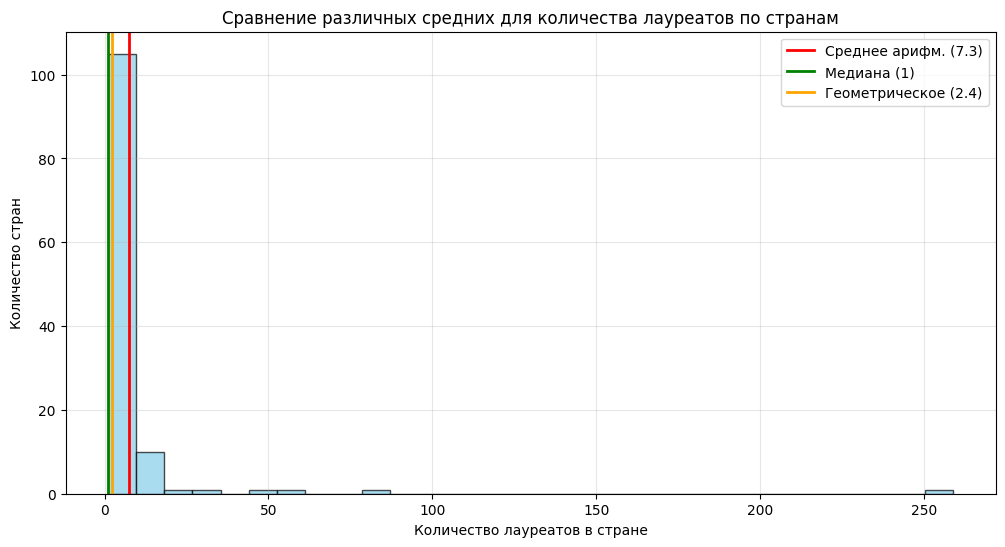

ДЕТАЛЬНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ

Страна-лидер: United States of America с 259 лауреатами
Вторая страна: United Kingdom с 85 лауреатами

Стран с ≤ 5 лауреатами: 96 (79.3%)


In [70]:
# Расчёт различных средних
mean_arith = country_counts.mean()
median = country_counts.median()
mode_val = country_counts.mode()[0]
geo_mean = gmean(country_counts)

print("СРАВНЕНИЕ СРЕДНИХ ДЛЯ КОЛИЧЕСТВА ЛАУРЕАТОВ ПО СТРАНАМ")
print(f"Среднее арифметическое: {mean_arith:.2f}")
print(f"Медиана: {median:.0f}")
print(f"Мода: {mode_val:.0f}")
print(f"Геометрическое среднее: {geo_mean:.2f}")

# Дополнительная статистика
print(f"\nМинимум: {country_counts.min()}")
print(f"Максимум: {country_counts.max()}")
print(f"Стандартное отклонение: {country_counts.std():.2f}")

# Квартили
print(f"\nQ1 (25%): {country_counts.quantile(0.25):.0f}")
print(f"Q2 (медиана): {country_counts.quantile(0.5):.0f}")
print(f"Q3 (75%): {country_counts.quantile(0.75):.0f}")

plt.figure(figsize=(12, 6))

# Гистограмма с линиями средних
plt.hist(country_counts, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_arith, color='red', linestyle='-', linewidth=2, label=f'Среднее арифм. ({mean_arith:.1f})')
plt.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Медиана ({median:.0f})')
plt.axvline(geo_mean, color='orange', linestyle='-', linewidth=2, label=f'Геометрическое ({geo_mean:.1f})')

plt.title('Сравнение различных средних для количества лауреатов по странам')
plt.xlabel('Количество лауреатов в стране')
plt.ylabel('Количество стран')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ДЕТАЛЬНЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ")

# Страны-лидеры
print(f"\nСтрана-лидер: {country_counts.index[0]} с {country_counts.values[0]} лауреатами")
print(f"Вторая страна: {country_counts.index[1]} с {country_counts.values[1]} лауреатами")

# Большинство стран
countries_with_few = country_counts[country_counts <= 5]
print(f"\nСтран с ≤ 5 лауреатами: {len(countries_with_few)} ({len(countries_with_few)/len(country_counts)*100:.1f}%)")

### Почему средние различаются?

| Среднее | Значение | Почему такое |
|---------|----------|--------------|
| **Среднее арифметическое** | 7.31 | Сильно завышено из-за стран-лидеров (например, США с 259 лауреатами) |
| **Медиана** | 1 | Показывает типичную страну (большинство стран имеют 1 лауреата) |
| **Мода** | 1 | Самое частое значение — 1 лауреат |
| **Геометрическое среднее** | 2.36 | Промежуточное значение, менее чувствительно к выбросам, чем арифметическое |

### Какое среднее лучше отражает «типичное» значение?

Медиана (1) — лучший показатель "типичной" страны, потому что:

1. Устойчива к выбросам — не зависит от того, что у США 259 лауреатов
2. Честно отражает реальность — больше половины стран действительно имеют только 1 лауреата
3. Не искажается асимметрией распределения

Среднее арифметическое (7.31) здесь вводит в заблуждение:
- Оно показывает, что "в среднем на страну приходится 7.3 лауреата"
- Но на самом деле более 50% стран имеют только 1 лауреата
- Такое среднее создаёт ложное впечатление, что у типичной страны несколько лауреатов

### Вывод

Для сильно асимметричных распределений (как количество лауреатов по странам) медиана даёт более правдивое представление о "типичном" значении, чем среднее арифметическое. В данном случае типичная страна имеет всего 1 лауреата, несмотря на то что среднее арифметическое показывает 7.3.

## Задание 7. Неправильная диаграмма

Выберем визуализацию из первой части работы: boxplot зависимости возраста от категории.

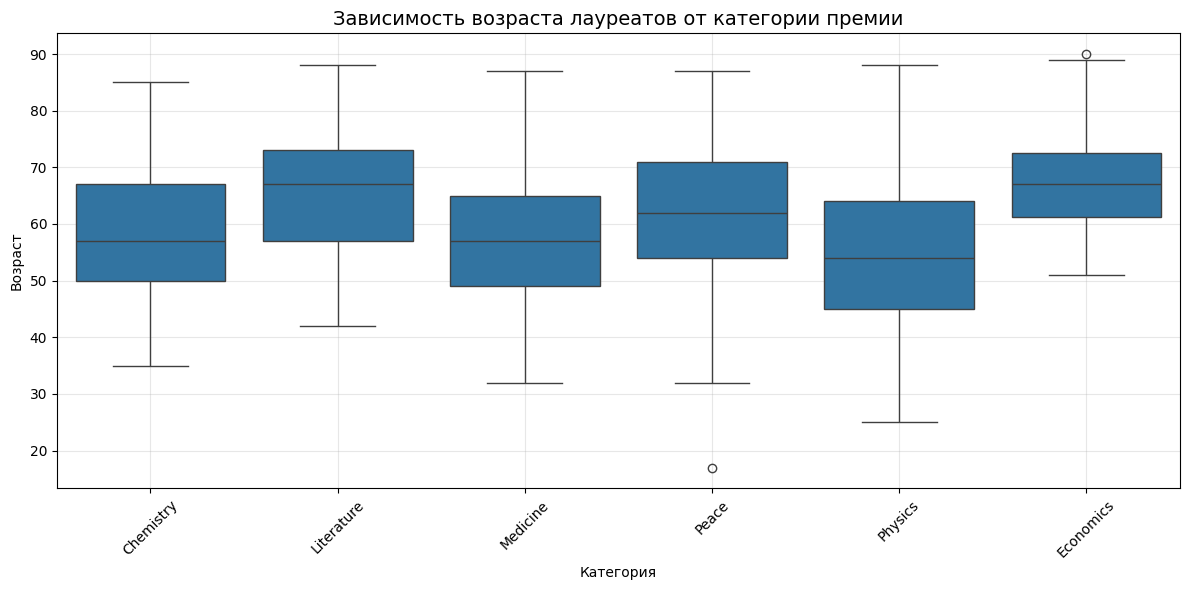

In [41]:
# Исходный график из первой части
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='category', y='age')
plt.title('Зависимость возраста лауреатов от категории премии', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Возраст')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Какая диаграмма была бы хуже?

Круговая диаграмма для этих же данных — попытка показать распределение возраста по категориям в виде круга.

**Что она исказит:**
- Нельзя показать распределение возраста внутри категории
- Нельзя сравнить медианы и разброс
- При большом количестве категорий круговая диаграмма становится нечитаемой
- Потеря информации о выбросах

**Какой неверный вывод мог бы сделать зритель:**
- "В физике все лауреаты примерно одного возраста" (на самом деле там большой разброс)
- "В экономике возраст не важен" (на самом деле там самые возрастные)
- "Категории примерно равны по возрасту" (на самом деле различия существенны)

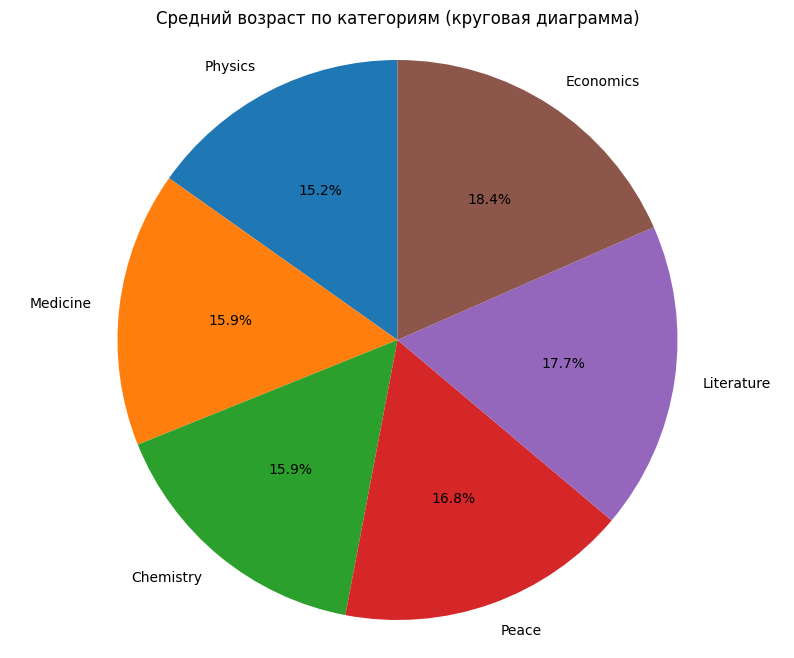

Проблемы этой визуализации:
1. Не виден разброс значений внутри категорий
2. Не видны выбросы
3. Проценты вводят в заблуждение — создаётся впечатление, что категории сравнимы по доле, хотя это просто средние
4. Потеряна информация о медианах, квартилях, экстремумах


In [50]:
# Демонстрация "плохой" визуализации (круговой диаграммы)
mean_age_by_cat = df.groupby('category')['age'].mean().sort_values()

plt.figure(figsize=(10, 8))
plt.pie(mean_age_by_cat.values, labels=mean_age_by_cat.index, autopct='%1.1f%%', startangle=90)
plt.title('Средний возраст по категориям (круговая диаграмма)')
plt.axis('equal')
plt.show()

print("Проблемы этой визуализации:")
print("1. Не виден разброс значений внутри категорий")
print("2. Не видны выбросы")
print("3. Проценты вводят в заблуждение — создаётся впечатление, что категории сравнимы по доле, хотя это просто средние")
print("4. Потеряна информация о медианах, квартилях, экстремумах")

## Задание 8. Одна и та же информация — разные графики

Для пары признаков **`category`** (категория) и **`age`** (возраст) построим два разных типа визуализации.

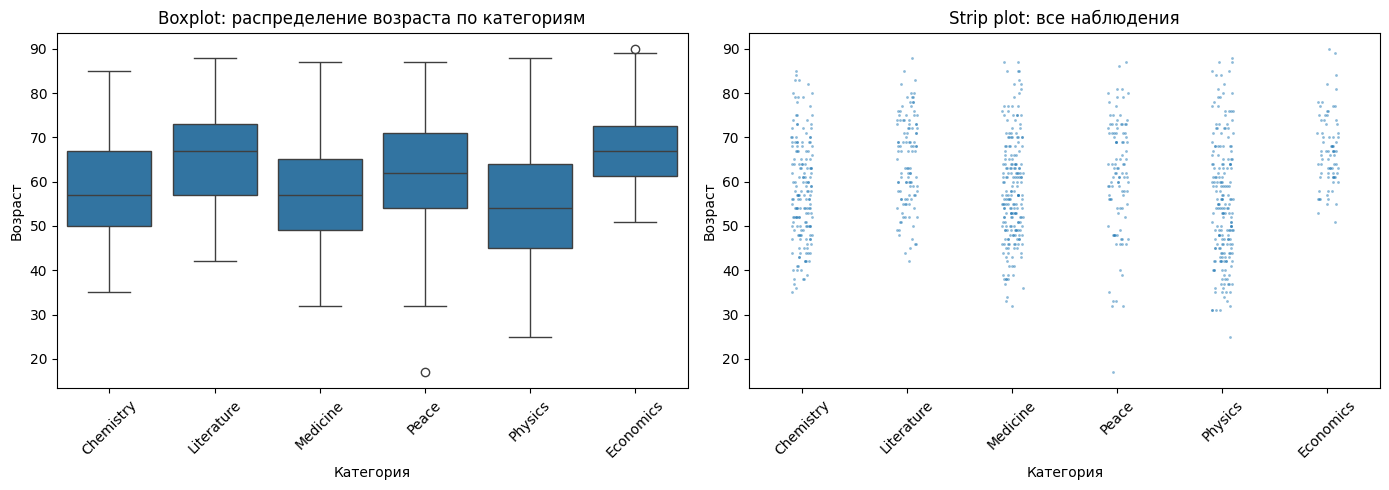

In [64]:
# График 1: Boxplot (уже был)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='category', y='age')
plt.title('Boxplot: распределение возраста по категориям')
plt.xlabel('Категория')
plt.ylabel('Возраст')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.stripplot(data=df, x='category', y='age', alpha=0.5, jitter=True, size=2)
plt.title('Strip plot: все наблюдения')
plt.xlabel('Категория')
plt.ylabel('Возраст')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Что показывает каждый график

Boxplot показывает общую картину распределения:
- медиану
- разброс значений
- возможные выбросы

С его помощью удобно сравнивать категории между собой и проверять гипотезы о том, в каких категориях лауреаты в среднем старше или моложе, а также где разброс возраста больше.

Strip plot показывает все отдельные наблюдения.  
По нему можно увидеть:
- где находится основная масса значений
- есть ли скопления точек
- встречаются ли редкие или необычные значения

Такой график лучше подходит для гипотез о форме распределения и о наличии отдельных редких наблюдений.

### Какие гипотезы легче заметить на каждом графике

На boxplot легче заметить такие гипотезы:
- в категории Economics медианный возраст выше, чем в Physics
- в категории Literature лауреаты в среднем старше, чем в Chemistry
- в категории Peace или Physics разброс возраста больше, чем в других категориях

Это легче увидеть, потому что boxplot хорошо показывает центр распределения и его ширину.

На strip plot легче заметить такие гипотезы:
- в большинстве категорий возраст лауреатов чаще всего находится примерно в диапазоне 50–70 лет
- в некоторых категориях есть редкие очень молодые или очень пожилые лауреаты
- распределение внутри категорий может быть неравномерным, то есть значения скапливаются в отдельных возрастных диапазонах

Это легче увидеть, потому что strip plot показывает все точки без обобщения.

### Вывод

Оба графика показывают одну и ту же зависимость между категорией и возрастом, но делают акцент на разной информации.

Boxplot лучше подходит для сравнения категорий и проверки гипотез о медиане, разбросе и выбросах.

Strip plot лучше подходит для проверки гипотез о плотности, скоплениях значений и редких наблюдениях.

Поэтому эти два графика лучше использовать вместе: один даёт краткую сводку, а второй помогает увидеть детали распределения.
